<a href="https://colab.research.google.com/github/Karishmaaa22/ML-safety/blob/main/Exercise7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
train_path = "/content/drive/MyDrive/Data2/train"
test_path = "/content/drive/MyDrive/Data2/test"

In [7]:
import pandas as pd
labels_train = pd.read_csv(train_path + "/labels.csv")
labels_test = pd.read_csv(test_path + "/labels.csv")

In [1]:
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


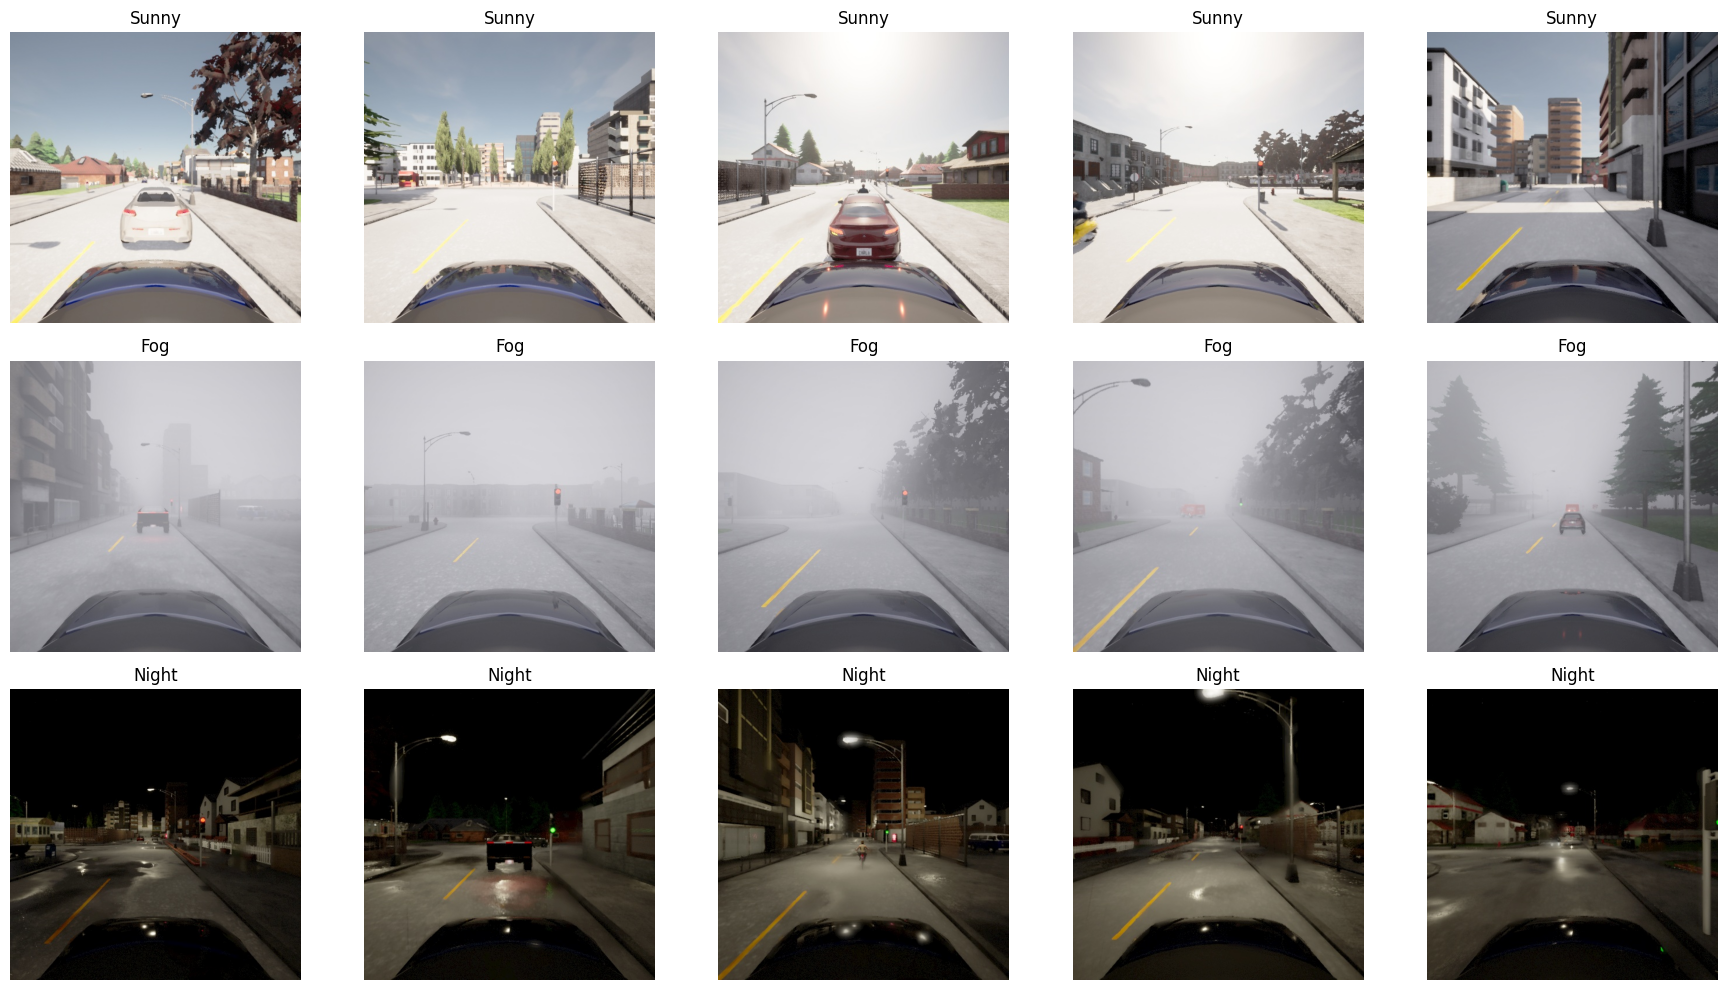

In [8]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
# IMAGE DIRECTORIES
train_rgb_path=train_path+"/rgb-front"
id_path = train_rgb_path

fog_path = "/content/drive/MyDrive/Data2/test-fog/rgb-front"

night_path = "/content/drive/MyDrive/Data2/test-night/rgb-front"

id_images = random.sample(
    os.listdir(id_path),
    5
)

fog_images = random.sample(
    os.listdir(fog_path),
    5
)

night_images = random.sample(
    os.listdir(night_path),
    5
)

fig, axes = plt.subplots(
    3,
    5,
    figsize=(18,10)
)

# Row 1: In-Distribution
for i, img_name in enumerate(id_images):

    img = Image.open(
        os.path.join(id_path, img_name)
    )

    axes[0, i].imshow(img)

    axes[0, i].set_title("Sunny")

    axes[0, i].axis("off")

# Row 2: Fog
for i, img_name in enumerate(fog_images):

    img = Image.open(
        os.path.join(fog_path, img_name)
    )

    axes[1, i].imshow(img)

    axes[1, i].set_title("Fog")

    axes[1, i].axis("off")

# Row 3: Night
for i, img_name in enumerate(night_images):

    img = Image.open(
        os.path.join(night_path, img_name)
    )

    axes[2, i].imshow(img)

    axes[2, i].set_title("Night")

    axes[2, i].axis("off")

plt.tight_layout()

plt.show()

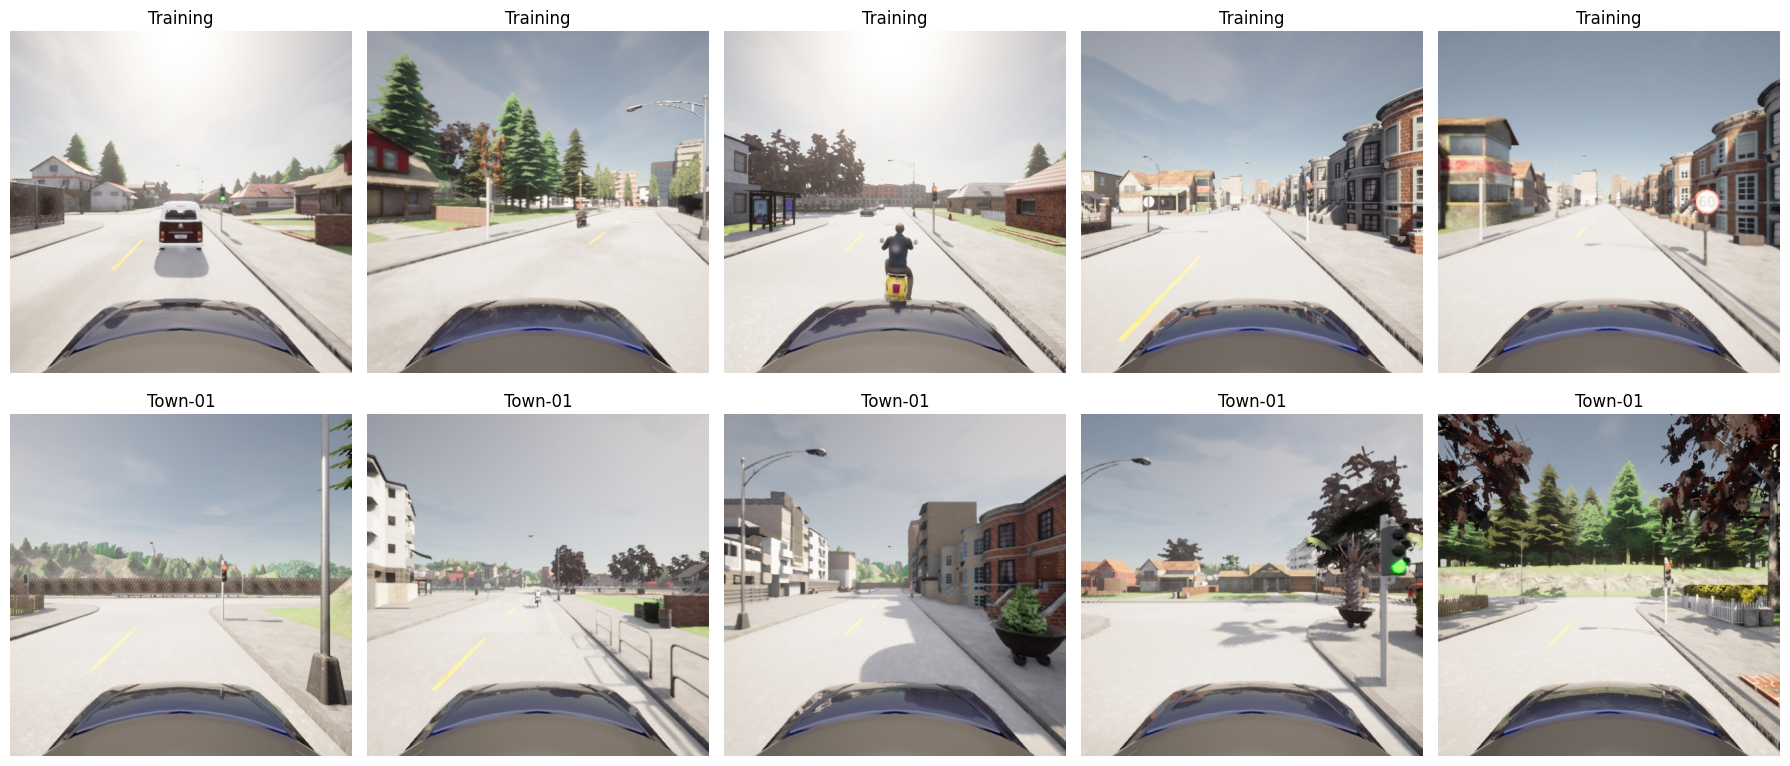

In [9]:
train_path = train_rgb_path

town_path = "/content/drive/MyDrive/Data2/test-town-01/rgb-front"

train_images = random.sample(
    os.listdir(train_path),
    5
)

town_images = random.sample(
    os.listdir(town_path),
    5
)


fig, axes = plt.subplots(
    2,
    5,
    figsize=(18,8)
)

for i, img_name in enumerate(train_images):

    img = Image.open(
        os.path.join(train_path, img_name)
    )

    axes[0, i].imshow(img)

    axes[0, i].set_title("Training")

    axes[0, i].axis("off")

for i, img_name in enumerate(town_images):

    img = Image.open(
        os.path.join(town_path, img_name)
    )

    axes[1, i].imshow(img)

    axes[1, i].set_title("Town-01")

    axes[1, i].axis("off")

plt.tight_layout()

plt.show()

In [10]:
from torch.utils.data import DataLoader
import numpy as np

def mean_confidence(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False
    )

    confidences = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            # confidence of predicted class
            conf = torch.maximum(
                probs,
                1 - probs
            )

            confidences.extend(
                conf.cpu().numpy().flatten()
            )

    return np.mean(confidences)

In [11]:
from torchvision import transforms

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor()

])

In [12]:
import torch.nn as nn
from torchvision import models

def create_model():

    model = models.resnet18(

        weights=models.ResNet18_Weights.DEFAULT
    )

    model.fc = nn.Linear(

        model.fc.in_features,

        1
    )

    return model

In [13]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torch

class CarlaDataset(Dataset):

    def __init__(

        self,

        dataframe,

        image_dir,

        label_column,

        transform=None
    ):

        self.dataframe = dataframe

        self.image_dir = image_dir

        self.label_column = label_column

        self.transform = transform

        self.image_files = sorted(
            os.listdir(image_dir)
        )

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        image_name = self.image_files[idx]

        image_path = os.path.join(

            self.image_dir,

            image_name
        )

        image = Image.open(

            image_path

        ).convert("RGB")

        label = torch.tensor(

            self.dataframe.iloc[idx][self.label_column],

            dtype=torch.float32
        )

        if self.transform:

            image = self.transform(image)

        return image, label

In [17]:
splits = {

    "In-Distribution":
    "/content/drive/MyDrive/Data2/test",

    "Fog":
    "/content/drive/MyDrive/Data2/test-fog",

    "Night":
    "/content/drive/MyDrive/Data2/test-night"
}

tasks = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]

for task in tasks:

    print("\n======================")
    print(task)
    print("======================")

    model = create_model().to(device)

    model.load_state_dict(
        torch.load(
            f"/content/drive/MyDrive/Data2/models/{task}_model.pth",
            map_location=device
        )
    )

    for split_name, split_path in splits.items():

        labels = pd.read_csv(
            split_path + "/labels.csv"
        )

        dataset = CarlaDataset(
            dataframe=labels,
            image_dir=split_path + "/rgb-front",
            label_column=task,
            transform=transform
        )

        confidence = mean_confidence(
            model,
            dataset
        )

        print(
            f"{split_name}: "
            f"{confidence:.4f}"
        )


has_pedestrian
In-Distribution: 0.9232
Fog: 0.9580
Night: 0.9081

has_traffic_light
In-Distribution: 0.9868
Fog: 0.8600
Night: 0.8888

has_vehicle
In-Distribution: 0.9435
Fog: 0.8964
Night: 0.8818


In [18]:
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

def get_ood_scores(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False
    )

    scores = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            confidence = torch.maximum(
                probs,
                1 - probs
            )

            ood_score = 1 - confidence

            scores.extend(
                ood_score.cpu().numpy().flatten()
            )

    return np.array(scores)

In [22]:
labels_test = pd.read_csv(
    "/content/drive/MyDrive/Data2/test/labels.csv"
)

labels_fog = pd.read_csv(
    "/content/drive/MyDrive/Data2/test-fog/labels.csv"
)

labels_night = pd.read_csv(
    "/content/drive/MyDrive/Data2/test-night/labels.csv"
)

In [19]:
ped_model = create_model().to(device)

ped_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/models/has_pedestrian_model.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [25]:
test_rgb_path= test_path+"/rgb-front"
fog_rgb_path="/content/drive/MyDrive/Data2/test-fog/rgb-front"
night_rgb_path="/content/drive/MyDrive/Data2/test-night/rgb-front"
id_dataset = CarlaDataset(
    labels_test,
    test_rgb_path,
    "has_pedestrian",
    transform
)

fog_dataset = CarlaDataset(
    labels_fog,
    fog_rgb_path,
    "has_pedestrian",
    transform
)

night_dataset = CarlaDataset(
    labels_night,
    night_rgb_path,
    "has_pedestrian",
    transform
)

In [26]:
id_scores = get_ood_scores(
    ped_model,
    id_dataset
)

fog_scores = get_ood_scores(
    ped_model,
    fog_dataset
)

night_scores = get_ood_scores(
    ped_model,
    night_dataset
)

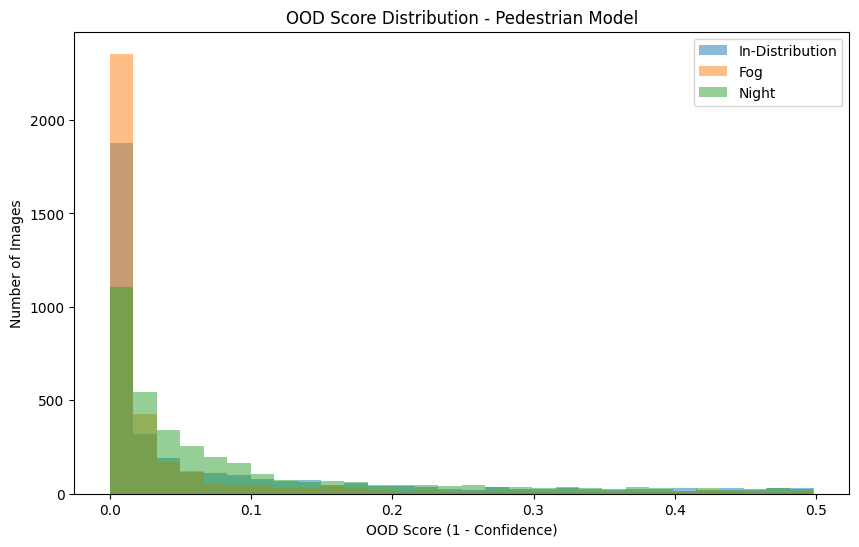

In [27]:
plt.figure(figsize=(10,6))

plt.hist(
    id_scores,
    bins=30,
    alpha=0.5,
    label="In-Distribution"
)

plt.hist(
    fog_scores,
    bins=30,
    alpha=0.5,
    label="Fog"
)

plt.hist(
    night_scores,
    bins=30,
    alpha=0.5,
    label="Night"
)

plt.xlabel("OOD Score (1 - Confidence)")
plt.ylabel("Number of Images")
plt.title(
    "OOD Score Distribution - Pedestrian Model"
)

plt.legend()

plt.show()

In [28]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true_fog = np.concatenate([
    np.zeros(len(id_scores)),   # In-Distribution
    np.ones(len(fog_scores))    # OOD
])

y_scores_fog = np.concatenate([
    id_scores,
    fog_scores
])

auroc_fog = roc_auc_score(
    y_true_fog,
    y_scores_fog
)

print("AUROC (Fog):", auroc_fog)

AUROC (Fog): 0.47168989197530864


In [29]:
y_true_night = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(night_scores))
])

y_scores_night = np.concatenate([
    id_scores,
    night_scores
])

auroc_night = roc_auc_score(
    y_true_night,
    y_scores_night
)

print("AUROC (Night):", auroc_night)

AUROC (Night): 0.6374418981481481


In [30]:
combined_ood_scores = np.concatenate([
    fog_scores,
    night_scores
])

y_true_all = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(combined_ood_scores))
])

y_scores_all = np.concatenate([
    id_scores,
    combined_ood_scores
])

auroc_all = roc_auc_score(
    y_true_all,
    y_scores_all
)

print("AUROC (All OOD):", auroc_all)

AUROC (All OOD): 0.5545658950617284


In [31]:
import torch
import torch.nn as nn

feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [32]:
from torch.utils.data import DataLoader
import numpy as np

def extract_features(dataset):

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False
    )

    features = []

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            feats = feature_extractor(images)

            feats = feats.view(
                feats.size(0),
                -1
            )

            features.append(
                feats.cpu().numpy()
            )

    return np.vstack(features)

In [33]:
train_dataset = CarlaDataset(
    labels_train,
    train_rgb_path,
    "has_pedestrian",
    transform
)

id_dataset = CarlaDataset(
    labels_test,
    test_rgb_path,
    "has_pedestrian",
    transform
)

fog_dataset = CarlaDataset(
    labels_fog,
    fog_rgb_path,
    "has_pedestrian",
    transform
)

night_dataset = CarlaDataset(
    labels_night,
    night_rgb_path,
    "has_pedestrian",
    transform
)

In [34]:
train_features = extract_features(
    train_dataset
)

id_features = extract_features(
    id_dataset
)

fog_features = extract_features(
    fog_dataset
)

night_features = extract_features(
    night_dataset
)

print(train_features.shape)
print(id_features.shape)
print(fog_features.shape)
print(night_features.shape)

(7200, 512)
(3600, 512)
(3600, 512)
(3600, 512)


In [35]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)

knn.fit(train_features)
#Score In-distribution test images
id_distances, _ = knn.kneighbors(
    id_features
)

id_scores = id_distances.flatten()

In [36]:
fog_distances, _ = knn.kneighbors(
    fog_features
)

fog_scores = fog_distances.flatten()

In [37]:
night_distances, _ = knn.kneighbors(
    night_features
)

night_scores = night_distances.flatten()

In [38]:
print("Mean ID Distance:",
      np.mean(id_scores))

print("Mean Fog Distance:",
      np.mean(fog_scores))

print("Mean Night Distance:",
      np.mean(night_scores))

Mean ID Distance: 2.992899076309469
Mean Fog Distance: 4.555085812608401
Mean Night Distance: 6.200657866067356


In [39]:
from sklearn.metrics import roc_auc_score
import numpy as np
#Fog AUROC
y_true_fog = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(fog_scores))
])

y_scores_fog = np.concatenate([
    id_scores,
    fog_scores
])

auroc_fog_knn = roc_auc_score(
    y_true_fog,
    y_scores_fog
)

print("k-NN AUROC (Fog):",
      auroc_fog_knn)
#Night AUROC

y_true_night = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(night_scores))
])

y_scores_night = np.concatenate([
    id_scores,
    night_scores
])

auroc_night_knn = roc_auc_score(
    y_true_night,
    y_scores_night
)

print("k-NN AUROC (Night):",
      auroc_night_knn)

# ALL OOD AUROC

all_ood_scores = np.concatenate([
    fog_scores,
    night_scores
])

y_true_all = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(all_ood_scores))
])

y_scores_all = np.concatenate([
    id_scores,
    all_ood_scores
])

auroc_all_knn = roc_auc_score(
    y_true_all,
    y_scores_all
)

print("k-NN AUROC (All OOD):",
      auroc_all_knn)

k-NN AUROC (Fog): 0.7808180941358025
k-NN AUROC (Night): 0.963186188271605
k-NN AUROC (All OOD): 0.8720021412037036
